In [1]:
%pylab widget
%load_ext autoreload
%autoreload 2
# %load_ext memory_profiler

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


## GECCO CNS Patient

In [2]:
# Read the mhd file from data
from gecco import patient_data
import gecco as fc
import numpy as np
from gecco.utils import nrrd_to_mhd
import mpl_interactions as pli

import matplotlib.pyplot as plt
from scipy.ndimage import zoom, gaussian_filter
import SimpleITK as sitk

In [3]:
nrrd_file = '/media/jericho/T7/dfci_laptop_backup/Documents/christian_patient_data/BRAIN/2_Stereo_CNS_Scan.nrrd'
nrrd_to_mhd(nrrd_file,force=True)
phantom = patient_data.patient_phantom(nrrd_file, 1e10, is_fullfan=False)#, reload=True, sim_num=7)
phantom.out_dir ='/home/jericho/Software/gecco/gecco/data/user_phantoms/2_Stereo_CNS_Scan/fastmc_output_7'
# Loading the previous GGEMS
phantom.load_ggems()

[2024-07-12 16:51:40,136] {utils.py:673} INFO - Directory /home/jericho/Software/gecco/gecco/data/user_phantoms/2_Stereo_CNS_Scan already exists, but is being overwriten
[2024-07-12 16:51:40,137] {utils.py:678} INFO - Creating directory 2_Stereo_CNS_Scan


[2024-07-12 16:51:41,283] {utils.py:771} INFO - Transposing the data
[2024-07-12 16:51:41,284] {utils.py:773} INFO - The spacing is [1.25     0.761719 0.761719]
[2024-07-12 16:51:41,284] {utils.py:775} INFO - The origin is [-229.5 -195.  -195. ]
[2024-07-12 16:51:41,284] {utils.py:776} INFO - The shape is (296, 512, 512)
[2024-07-12 16:51:41,506] {utils.py:744} INFO -     Processing HU section 0
[2024-07-12 16:51:41,616] {utils.py:744} INFO -     Processing HU section 1
[2024-07-12 16:51:41,697] {utils.py:744} INFO -     Processing HU section 2
[2024-07-12 16:51:41,767] {utils.py:744} INFO -     Processing HU section 3
[2024-07-12 16:51:41,843] {utils.py:744} INFO -     Processing HU section 4
[2024-07-12 16:51:41,906] {utils.py:744} INFO -     Processing HU section 5
[2024-07-12 16:51:41,969] {utils.py:744} INFO -     Processing HU section 6
[2024-07-12 16:51:42,033] {utils.py:744} INFO -     Processing HU section 7
[2024-07-12 16:51:42,114] {utils.py:744} INFO -     Processing HU sec

/home/jericho/Software/gecco/gecco/spectrum.py:121: RuntimeWarning: divide by zero encountered in log
  log_y = np.log(yy)


[2024-07-12 16:51:44,701] {utils.py:803} INFO - Phantom Created
To load the phantom from the mhd file use the following command: 
phantom = patient_phantom.patient_phantom("/media/jericho/T7/dfci_laptop_backup/Documents/christian_patient_data/BRAIN/2_Stereo_CNS_Scan.nrrd",[nparticles])
[2024-07-12 16:51:45,006] {utils.py:186} INFO - Using default geometry, DSD = 1510, nDetector = [512, 512], dDetector = [0.784, 0.784]
[2024-07-12 16:51:45,007] {utils.py:496} INFO - Loading density data from file
[2024-07-12 16:51:45,008] {utils.py:552} INFO - Loading attenuation files from /home/jericho/Software/gecco/gecco/data/user_phantoms/2_Stereo_CNS_Scan/2_Stereo_CNS_Scan_materials.txt
[2024-07-12 16:51:45,008] {utils.py:553} INFO - Making attenuation files in gecco:
[2024-07-12 16:51:45,009] {utils.py:557} INFO -     Air atten file already exists, skipping...
[2024-07-12 16:51:45,009] {utils.py:557} INFO -     polyurethane atten file already exists, skipping...
[2024-07-12 16:51:45,009] {utils.p

Shift phantom position

In [142]:
phantom.phantom = phantom.phantom[:,60:,:]
phantom.density = phantom.density[:,60:,:]
phantom.geomet.nVoxel = np.array(phantom.phantom.shape)
phantom.geomet.sVoxel = phantom.geomet.nVoxel*phantom.geomet.dVoxel

In [146]:
# Source spectrum
spectrum = fc.calculate_spectrum_sp(100,12)

# Beam filters
spectrum.filter('Be', 1.5)
spectrum.filter('Al', 2.75)
spectrum.filter('Ti', 0.89)

# Detector filters
spectrum.filter('Al', 3.7)
spectrum.filter('C', 3.8*(2/1.7)) # Difference in density

phantom.detector_material = 'CsI'
phantom.xx, phantom.yy = spectrum.get_points()
phantom.run_gecco(1e16,815,conv_on=False)

[2024-07-12 14:09:51,053] {patient_data.py:616} INFO - Making a list of angles
[2024-07-12 14:09:51,054] {patient_data.py:644} INFO - Detector matching specifications: CsI-784-micrometer
[2024-07-12 14:09:51,057] {ggems_simulate.py:204} INFO - Initializing filter /home/jericho/Software/gecco/gecco/data/bowties/no_bowtie.dat
[2024-07-12 14:09:52,316] {ggems_simulate.py:581} INFO - Running Simulations: 815 Projections
[2024-07-12 14:09:52,317] {ggems_simulate.py:609} INFO -     Simulating 10 keV
[2024-07-12 14:09:52,339] {ggems_simulate.py:688} INFO -         Attenuation at 10 keV for SchneiderMaterialsWeight2 is 10.349854284535223
[2024-07-12 14:09:52,352] {ggems_simulate.py:688} INFO -         Attenuation at 10 keV for SchneiderMaterialsWeight3 is 5.647085846302243
[2024-07-12 14:09:52,366] {ggems_simulate.py:688} INFO -         Attenuation at 10 keV for SchneiderMaterialsWeight4 is 6.434291404998359
[2024-07-12 14:09:52,380] {ggems_simulate.py:688} INFO -         Attenuation at 10 keV

In [147]:
print(phantom.geomet)
print(phantom_rtis.geomet)

TIGRE parameters
-----
Geometry parameters
Distance from source to detector (DSD) = 1510 mm
Distance from source to origin (DSO)= 1000.0 mm
-----
Detector parameters
Number of pixels (nDetector) = [512 512]
Size of each pixel (dDetector) = [0.784 0.784] mm
Total size of the detector (sDetector) = [401.408 401.408] mm
-----
Image parameters
Number of voxels (nVoxel) = [296 452 512]
Total size of the image (sVoxel) = [370.       344.296988 390.000128] mm
Size of each voxel (dVoxel) = [1.25     0.761719 0.761719] mm
-----
Offset correction parameters
Offset of image from origin (offOrigin) = [0 0 0] mm
Offset of detector (offDetector) = [   0 -160] mm
-----
Auxillary parameters
Samples per pixel of forward projection (accuracy) = 0.5
-----
Rotation of the Detector (rotDetector) = [0 0 0] rad
TIGRE parameters
-----
Geometry parameters
Distance from source to detector (DSD) = 1510 mm
Distance from source to origin (DSO)= 1000.0 mm
-----
Detector parameters
Number of pixels (nDetector) = [  

In [144]:
phantom.correct_intensity(ml=False,crop=40)

AttributeError: 'patient_phantom' object has no attribute 'primary_projections'

In [204]:
phantom.sim_angles = np.linspace(0,2*np.pi,45)
phantom.interpolate_ggems_scatter()
phantom.calc_gecco_projections(scat_weight=0.25,noise_weight=20) # Creates the gecco projections scatter to primary reduction from asg is 0.48 assumed half is taken by scatter correction
# phantom.add_poisson_noise(0.5)
phantom.reconstruct_ggems(algo="FDK",filt='ram_lak') # recon2structs creates phantom.img => reconstructed image

### Optional bhc (not used in paper)

In [ ]:
# These are the beam hardening corrections
fits = np.load('/home/jericho/1-Workspace/3-jupyter_notebooks_patient/7-bhc/fits.npy')
# Turn on for the beam hardening correction
for i in range(phantom.gecco_projections.shape[2]):
    p = np.poly1d(fits[i])
    phantom.gecco_projections[:,:,i] = p(phantom.gecco_projections[:,:,i])

### Plotting functions

In [ ]:
ct_file = '/media/jericho/T7/dfci_laptop_backup/Documents/christian_patient_data/BRAIN/2_Stereo_CNS_Scan.nrrd'
cbct_file = '/media/jericho/T7/dfci_laptop_backup/Documents/christian_patient_data/BRAIN/2_Unnamed_Series_1.nrrd'

ct = sitk.ReadImage(ct_file)
cbct = sitk.ReadImage(cbct_file)

ct = sitk.GetArrayFromImage(ct)
cbct = sitk.GetArrayFromImage(cbct)

cbct = np.flip(cbct, axis=2)

water_cbct = np.mean(cbct[79,236:250,285:300])
air_cbct = np.mean(cbct[79,0:10,0:10])
cbct_hu = (cbct - water_cbct)/(water_cbct-air_cbct) * 1000

img = phantom.img[139].squeeze()
water = np.mean(img[236:250,285:300])
air = np.mean(img[120:180,60:140])
# convert to HU using the water calibration
img = (img - water)/(water - air) * 1000
# img = gaussian_filter(img,1)

img[img<-1000] = -1000

img_noise = img #np.load('815_proj_HU_noise.npy')
# img = img #np.load('815_proj_HU_no_noise.npy')
img = gaussian_filter(img,1)
img2 = gaussian_filter(img,2)
img_noise = gaussian_filter(img_noise,.5)

/tmp/ipykernel_6419/2181809885.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_6419/2181809885.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Mean difference: 14.15 HU
Standard deviation: 39.27 HU


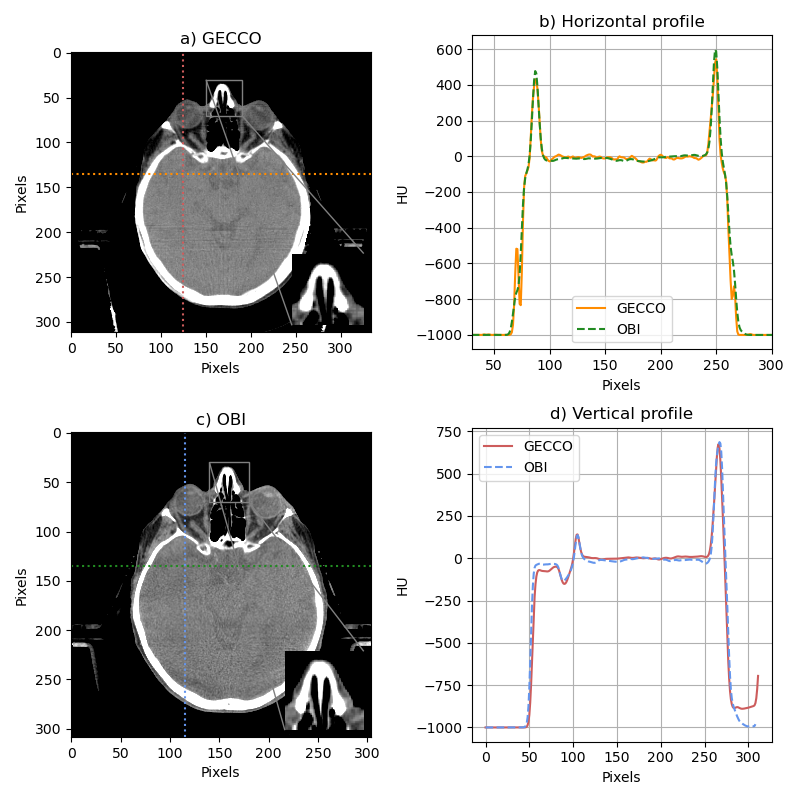

In [328]:
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes, mark_inset
plt.figure(figsize=(8,8))

cbct_hu_clean = zoom(cbct_hu[79:81].mean(axis=0),0.511/0.761)
cbct_hu2 = gaussian_filter(cbct_hu_clean,2)
index = 115
index2 = 124
crop = [60,80,88,90]

plt.subplot(2,2,1)
plt.imshow(img_noise[crop[0]:-crop[1],crop[2]:-crop[3]], cmap='gray', vmin=-200, vmax=200)
# indicate the profile with a red dotted axis horizontal line
plt.axhline(135, color='darkorange', linestyle=':')
plt.axvline(index2, color='indianred', linestyle=':')
plt.xlabel('Pixels')
plt.ylabel('Pixels')
plt.title('a) GECCO')

ax = plt.gca()
ax_inset = zoomed_inset_axes(ax, 2, loc='lower right')
ax_inset.imshow(img_noise[crop[0]:-crop[1],crop[2]:-crop[3]], cmap='gray', vmin=-200, vmax=200)
ax_inset.set_ylim(70,30)
ax_inset.set_xlim(150,190)
ax_inset.axis('off')
# plt.axis('off')
mark_inset(ax, ax_inset, loc1=1, loc2=3, fc="none", ec="0.5")
plt.subplot(2,2,3)
plt.imshow(cbct_hu_clean[15:-20,10:-30], cmap='gray', vmin=-200, vmax=200)
plt.axhline(135, color='forestgreen', linestyle=':')
plt.axvline(index, color='cornflowerblue', linestyle=':')
plt.xlabel('Pixels')
plt.ylabel('Pixels')
plt.title('c) OBI')

ax = plt.gca()
ax_inset = zoomed_inset_axes(ax, 2, loc='lower right')
ax_inset.imshow(cbct_hu_clean[15:-20,10:-30], cmap='gray', vmin=-200, vmax=200)
ax_inset.set_ylim(70,30)
ax_inset.set_xlim(140,180)
ax_inset.axis('off')
# plt.axis('off')
mark_inset(ax, ax_inset, loc1=1, loc2=3, fc="none", ec="0.5")

plt.subplot(2,2,2)
profile = img[300,:]

# x1 = np.arange(crop[2], img.shape[1]-crop[3])
# x2 = np.linspace(0, 512,cbct_hu2.shape[1])
plt.plot(img[135+crop[0],crop[2]:-crop[3]], label='GECCO', c='darkorange')
plt.plot(cbct_hu2[135 + 15], label='OBI', c = 'forestgreen', linestyle='--')
plt.xlim(30,300)
# plt.xlim(100,410)
plt.legend()
plt.title('b) Horizontal profile')
plt.xlabel('Pixels')
plt.ylabel('HU')
plt.grid('on')
plt.tight_layout()

plt.subplot(2,2,4)
plt.plot(img2[crop[0]:-crop[1],index2+crop[2]], label='GECCO', c='indianred')
plt.plot(cbct_hu2[15:-20,index+12], label='OBI', c = 'cornflowerblue', linestyle='--')

# plt.xlim(100,410)
plt.legend()
plt.title('d) Vertical profile')
plt.xlabel('Pixels')
plt.ylabel('HU')
plt.grid('on')
plt.tight_layout()
# Interpolate the profile to the same length
from scipy.interpolate import interp1d

# f1 = interp1d(x1, img[199,crop[2]:-crop[3]])
# f2 = interp1d(x2, cbct_hu2[127,10:-20])

# x = np.linspace(100,410,512)
# plt.figure()
# plt.plot(x, f1(x), label='GECCO', c='darkorange')
# plt.plot(x, f2(x), label='CBCT', c = 'forestgreen', linestyle='--')
# plt.legend()
# plt.colorbar(label='HU')   
prof = np.abs(img[135+crop[0],crop[2]:-crop[3]] - cbct_hu2[135 + 15,:-10])
# Calculate the difference between the two profiles
mean_diff = np.mean(prof[img[135+crop[0],crop[2]:-crop[3]]>-250])
std_diff = np.std(np.abs(img[135+crop[0],crop[2]:-crop[3]] - cbct_hu2[135 + 15,:-10]))

# prof2 = np.abs(img2[crop[0]:-crop[1],index2+crop[2]] - cbct_hu2[15:-20,index+12])
# # Calculate the difference between the two profiles
# mean_diff2 = np.mean(prof2[img2[crop[0]:-crop[1],index2+crop[2]]>-250])
# std_diff2 = np.std(np.abs(img2[crop[0]:-crop[1],index2+crop[2]] - cbct_hu2[15:-20,index+12]))
                   
plt.savefig('figure_4_CNS_GECCO.png', dpi=300)
print(f'Mean difference: {mean_diff:.2f} HU')
print(f'Standard deviation: {std_diff:.2f} HU')
# print(f'Mean difference: {mean_diff2:.2f} HU')
# print(f'Standard deviation: {std_diff2:.2f} HU')

## Look at the RTIS validation

In [69]:
# %%timeit
nrrd_file = '/media/jericho/T7/dfci_laptop_backup/Documents/christian_patient_data/BRAIN/2_Stereo_CNS_Scan.nrrd'
phantom_rtis = patient_data.patient_phantom(nrrd_file, 1e7, is_fullfan=False)

[2024-07-12 17:10:08,604] {utils.py:186} INFO - Using default geometry, DSD = 1510, nDetector = [512, 512], dDetector = [0.784, 0.784]
[2024-07-12 17:10:08,606] {utils.py:496} INFO - Loading density data from file
[2024-07-12 17:10:08,607] {utils.py:552} INFO - Loading attenuation files from /home/jericho/Software/gecco/gecco/data/user_phantoms/2_Stereo_CNS_Scan/2_Stereo_CNS_Scan_materials.txt
[2024-07-12 17:10:08,607] {utils.py:553} INFO - Making attenuation files in gecco:
[2024-07-12 17:10:08,607] {utils.py:557} INFO -     Air atten file already exists, skipping...
[2024-07-12 17:10:08,607] {utils.py:557} INFO -     polyurethane atten file already exists, skipping...
[2024-07-12 17:10:08,608] {utils.py:557} INFO -     teflon atten file already exists, skipping...
[2024-07-12 17:10:08,608] {utils.py:557} INFO -     pmp atten file already exists, skipping...
[2024-07-12 17:10:08,609] {utils.py:557} INFO -     bone50 atten file already exists, skipping...
[2024-07-12 17:10:08,609] {uti

In [70]:
spectrum = fc.calculate_spectrum_sp(100,12)

# Beam filters
spectrum.filter('Be', 1.5)
spectrum.filter('Al', 2.75)
spectrum.filter('Ti', 0.89)

# Detector filters
spectrum.filter('Al', 3.7)
spectrum.filter('C', 3.8*(2/1.7)) # Difference in density
phantom_rtis.initialize_fastmc(1, spectrum)

[2024-07-12 17:10:08,888] {patient_data.py:332} INFO - Making a list of angles
[2024-07-12 17:10:08,889] {fastmc_scatter.py:102} INFO - Half fan mode - for flood field
[2024-07-12 17:10:08,891] {fastmc_scatter.py:160} INFO - Saving simulation parameters to /home/jericho/Software/gecco/gecco/data/user_phantoms/2_Stereo_CNS_Scan/fastmc_simulation_20/fastmc_1e07_1angles.pkl
[2024-07-12 17:10:10,328] {fastmc_scatter.py:165} INFO - Done saving simulation parameters to /home/jericho/Software/gecco/gecco/data/user_phantoms/2_Stereo_CNS_Scan/fastmc_simulation_20/fastmc_1e07_1angles.pkl
[2024-07-12 17:10:10,328] {fastmc_scatter.py:33} INFO - Half fan mode - for projections
[2024-07-12 17:10:10,329] {patient_data.py:391} INFO - 


[2024-07-12 17:10:10,330] {patient_data.py:392} INFO - Fastmc simulation initialized
[2024-07-12 17:10:10,330] {patient_data.py:393} INFO -     Output directory: /home/jericho/Software/gecco/gecco/data/user_phantoms/2_Stereo_CNS_Scan/fastmc_output_53
[2024-07-12 17:10:

In [71]:
phantom_rtis.phantom = phantom_rtis.phantom[:,60:,:]
phantom_rtis.density = phantom_rtis.density[:,60:,:]

In [72]:
import numpy as np

phantom_rtis.phantom = phantom_rtis.phantom[139]
phantom_rtis.density = phantom_rtis.density[139]

# insert a new axis to the phantom
phantom_rtis.phantom = phantom_rtis.phantom[np.newaxis, ...]
phantom_rtis.density = phantom_rtis.density[np.newaxis, ...]

phantom_rtis.geomet.nVoxel = np.array([1,452, 512])
phantom_rtis.geomet.dVoxel = np.array([0.8, 0.8, 0.8])
phantom_rtis.geomet.sVoxel = phantom_rtis.geomet.dVoxel * phantom_rtis.geomet.nVoxel

phantom_rtis.geomet.nDetector = np.array([1, 512]) 
phantom_rtis.geomet.dDetector = np.array([phantom_rtis.geomet.dVoxel[0], 0.8])
phantom_rtis.geomet.sDetector = phantom_rtis.geomet.dDetector * phantom_rtis.geomet.nDetector

phantom_rtis.geomet.mode = "parallel"


In [73]:
# %%timeit
# phantom_rtis.bowtie_file = '/home/jericho/Software/gecco/gecco/data/bowties/no_bowtie.dat'
phantom_rtis.retain_partial_calcs = True
phantom_rtis.run_gecco(1e10,815,conv_on=False,filter_on=False)

[2024-07-12 17:10:10,407] {patient_data.py:616} INFO - Making a list of angles
[2024-07-12 17:10:10,407] {patient_data.py:644} INFO - Detector matching specifications: CsI-784-micrometer


[2024-07-12 17:10:10,411] {ggems_simulate.py:204} INFO - Initializing filter /home/jericho/Software/gecco/gecco/data/bowties/half_fan_mm.dat
[2024-07-12 17:10:10,418] {ggems_simulate.py:581} INFO - Running Simulations: 815 Projections
[2024-07-12 17:10:10,418] {ggems_simulate.py:609} INFO -     Simulating 10 keV
[2024-07-12 17:10:10,419] {ggems_simulate.py:688} INFO -         Attenuation at 10 keV for SchneiderMaterialsWeight2 is 10.349854284535223
[2024-07-12 17:10:10,420] {ggems_simulate.py:688} INFO -         Attenuation at 10 keV for SchneiderMaterialsWeight3 is 5.647085846302243
[2024-07-12 17:10:10,421] {ggems_simulate.py:688} INFO -         Attenuation at 10 keV for SchneiderMaterialsWeight4 is 6.434291404998359
[2024-07-12 17:10:10,422] {ggems_simulate.py:688} INFO -         Attenuation at 10 keV for SchneiderMaterialsWeight5 is 7.41921156863626
[2024-07-12 17:10:10,423] {ggems_simulate.py:688} INFO -         Attenuation at 10 keV for SchneiderMaterialsWeight6 is 8.095364893784

In [83]:
phantom_rtis.reweight(100,scat=0.05,mAs=400)

(815, 1, 512)


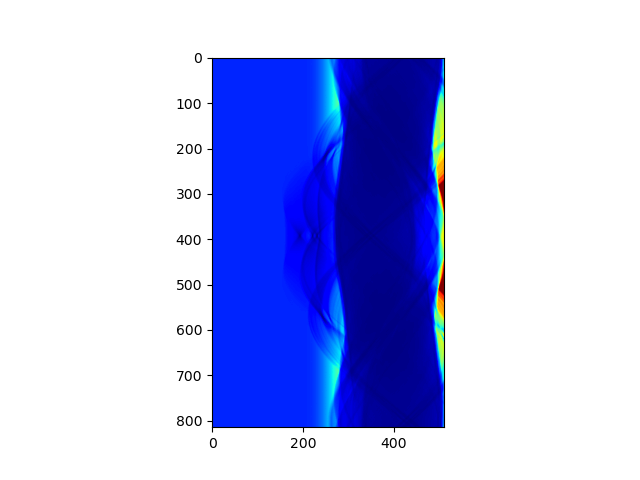

In [84]:
new_projs = []

for proj in phantom_rtis.primary_projections:
    new_projs.append(proj)

plt.figure()
plt.imshow(new_projs, cmap='jet')

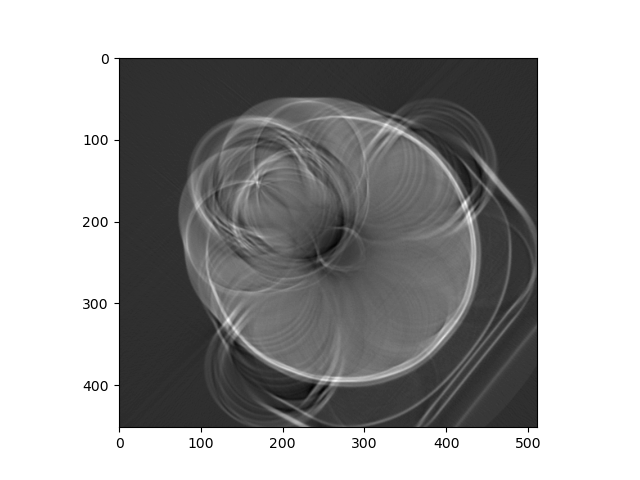

In [85]:
plt.figure()
plt.imshow(phantom_rtis.img[0], cmap='gray')

In [64]:
phantom_rtis.geomet.nDetector = np.array([10, 512])
phantom_rtis.geomet.sDetector = phantom_rtis.geomet.dDetector * phantom_rtis.geomet.nDetector

# tile by 10 along a new second axis
phantom_rtis.primary_projections = phantom_rtis.primary_projections[:,np.newaxis, ...]
phantom_rtis.primary_projections = np.tile(phantom_rtis.primary_projections, (1,10,1))

In [ ]:
phantom_rtis.nVoxel = np.array([1, 512, 452])
phantom_rtis.sVoxel = phantom_rtis.dVoxel * phantom_rtis.nVoxel

In [185]:
phantom_rtis.geomet.nVoxel = np.array([10,452, 512])
phantom_rtis.geomet.sVoxel = phantom_rtis.geomet.dVoxel * phantom_rtis.geomet.nVoxel

In [184]:
print(phantom_rtis.geomet)

TIGRE parameters
-----
Geometry parameters
Distance from source to detector (DSD) = 1510 mm
Distance from source to origin (DSO)= 1000.0 mm
-----
Detector parameters
Number of pixels (nDetector) = [ 10 512]
Size of each pixel (dDetector) = [0.8 0.8] mm
Total size of the detector (sDetector) = [  8.  409.6] mm
-----
Image parameters
Number of voxels (nVoxel) = [  1 452 512]
Total size of the image (sVoxel) = [  0.8 361.6 409.6] mm
Size of each voxel (dVoxel) = [0.8 0.8 0.8] mm
-----
Offset correction parameters
Offset of image from origin (offOrigin) = [0 0 0] mm
Offset of detector (offDetector) = [   0 -160] mm
-----
Auxillary parameters
Samples per pixel of forward projection (accuracy) = 0.5
-----
Rotation of the Detector (rotDetector) = [0 0 0] rad


In [174]:
phantom_rtis.flood_field = phantom_rtis.flood_field[:,np.newaxis, ...]
phantom_rtis.flood_field = np.tile(phantom_rtis.flood_field, (1,10,1))

In [175]:
phantom_rtis.flood_field.shape

(1, 5120, 1)

In [171]:
print(phantom_rtis.geomet)

TIGRE parameters
-----
Geometry parameters
Distance from source to detector (DSD) = 1510 mm
Distance from source to origin (DSO)= 1000.0 mm
-----
Detector parameters
Number of pixels (nDetector) = [ 10 512]
Size of each pixel (dDetector) = [0.8 0.8] mm
Total size of the detector (sDetector) = [  8.  409.6] mm
-----
Image parameters
Number of voxels (nVoxel) = [  1 452 512]
Total size of the image (sVoxel) = [  0.8 361.6 409.6] mm
Size of each voxel (dVoxel) = [0.8 0.8 0.8] mm
-----
Offset correction parameters
Offset of image from origin (offOrigin) = [0 0 0] mm
Offset of detector (offDetector) = [   0 -160] mm
-----
Auxillary parameters
Samples per pixel of forward projection (accuracy) = 0.5
-----
Rotation of the Detector (rotDetector) = [0 0 0] rad


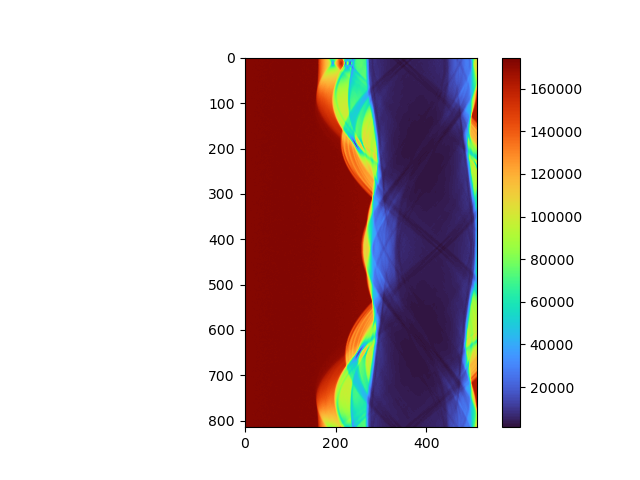

In [132]:
plt.figure()
plt.imshow(np.fliplr(phantom_rtis.primary_projections.squeeze()), cmap='turbo')
plt.colorbar()

/tmp/ipykernel_6419/1927898864.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_6419/1927898864.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Mean difference: 15.38 HU
Standard deviation: 33.75 HU


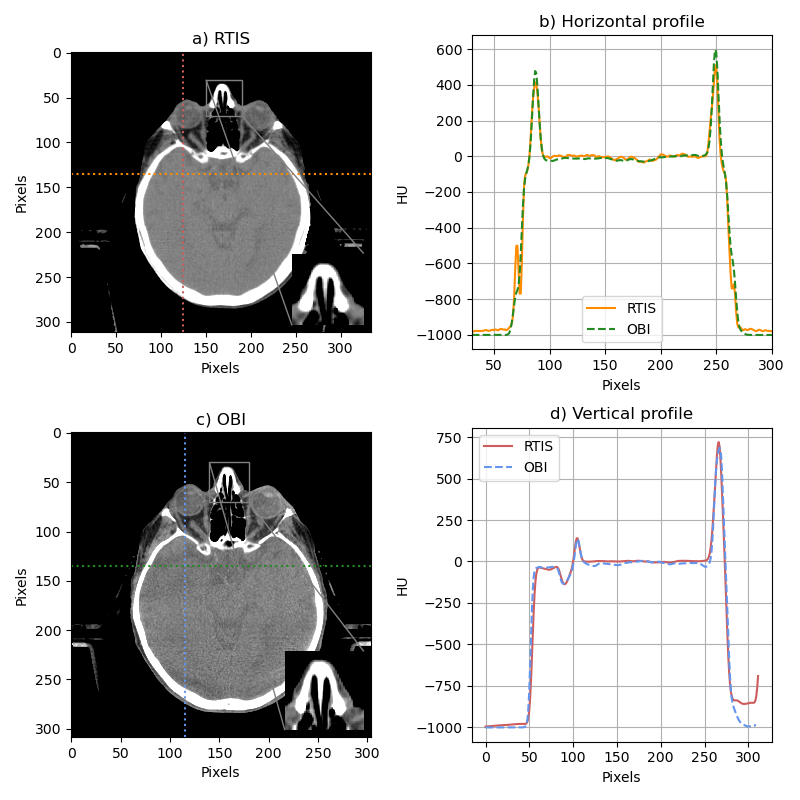

In [321]:
img = phantom_rtis.img.squeeze()
water = np.mean(img[236:250,285:300])
air = np.mean(img[120:180,60:140])
# convert to HU using the water calibration
img = (img - water)/(water - air) * 1000
# img = gaussian_filter(img,1)


img_noise = img #np.load('815_proj_HU_noise.npy')
# img = img #np.load('815_proj_HU_no_noise.npy')
img = gaussian_filter(img,1)
img2 = gaussian_filter(img,2)
img_noise = gaussian_filter(img_noise,.5)

plt.figure(figsize=(8,8))

cbct_hu_clean = zoom(cbct_hu[79:81].mean(axis=0),0.511/0.761)
cbct_hu2 = gaussian_filter(cbct_hu_clean,2)
index = 115
index2 = 124
crop = [60,80,88,90]

plt.subplot(2,2,1)
plt.imshow(img_noise[crop[0]:-crop[1],crop[2]:-crop[3]], cmap='gray', vmin=-200, vmax=200)
# indicate the profile with a red dotted axis horizontal line
plt.axhline(135, color='darkorange', linestyle=':')
plt.axvline(index2, color='indianred', linestyle=':')
plt.xlabel('Pixels')
plt.ylabel('Pixels')
plt.title('a) RTIS')
ax = plt.gca()
ax_inset = zoomed_inset_axes(ax, 2, loc='lower right')
ax_inset.imshow(img_noise[crop[0]:-crop[1],crop[2]:-crop[3]], cmap='gray', vmin=-200, vmax=200)
ax_inset.set_ylim(70,30)
ax_inset.set_xlim(150,190)
ax_inset.axis('off')
# plt.axis('off')
mark_inset(ax, ax_inset, loc1=1, loc2=3, fc="none", ec="0.5")
plt.subplot(2,2,3)
plt.imshow(cbct_hu_clean[15:-20,10:-30], cmap='gray', vmin=-200, vmax=200)
plt.axhline(135, color='forestgreen', linestyle=':')
plt.axvline(index, color='cornflowerblue', linestyle=':')
plt.xlabel('Pixels')
plt.ylabel('Pixels')
plt.title('c) OBI')

ax = plt.gca()
ax_inset = zoomed_inset_axes(ax, 2, loc='lower right')
ax_inset.imshow(cbct_hu_clean[15:-20,10:-30], cmap='gray', vmin=-200, vmax=200)
ax_inset.set_ylim(70,30)
ax_inset.set_xlim(140,180)
ax_inset.axis('off')
# plt.axis('off')
mark_inset(ax, ax_inset, loc1=1, loc2=3, fc="none", ec="0.5")

plt.subplot(2,2,2)
profile = img[300,:]

# x1 = np.arange(crop[2], img.shape[1]-crop[3])
# x2 = np.linspace(0, 512,cbct_hu2.shape[1])
plt.plot(img[135+crop[0],crop[2]:-crop[3]], label='RTIS', c='darkorange')
plt.plot(cbct_hu2[135 + 15], label='OBI', c = 'forestgreen', linestyle='--')
plt.xlim(30,300)
# plt.xlim(100,410)
plt.legend()
plt.title('b) Horizontal profile')
plt.xlabel('Pixels')
plt.ylabel('HU')
plt.grid('on')
plt.tight_layout()

plt.subplot(2,2,4)
plt.plot(img2[crop[0]:-crop[1],index2+crop[2]], label='RTIS', c='indianred')
plt.plot(cbct_hu2[15:-20,index+12], label='OBI', c = 'cornflowerblue', linestyle='--')

# plt.xlim(100,410)
plt.legend()
plt.title('d) Vertical profile')
plt.xlabel('Pixels')
plt.ylabel('HU')
plt.grid('on')
plt.tight_layout()

# Interpolate the profile to the same length
from scipy.interpolate import interp1d

# f1 = interp1d(x1, img[199,crop[2]:-crop[3]])
# f2 = interp1d(x2, cbct_hu2[127,10:-20])

# x = np.linspace(100,410,512)
# plt.figure()
# plt.plot(x, f1(x), label='GECCO', c='darkorange')
# plt.plot(x, f2(x), label='CBCT', c = 'forestgreen', linestyle='--')
# plt.legend()
# plt.colorbar(label='HU')   
prof = np.abs(img[135+crop[0],crop[2]:-crop[3]] - cbct_hu2[135 + 15,:-10])
# Calculate the difference between the two profiles
mean_diff = np.mean(prof[img[135+crop[0],crop[2]:-crop[3]]>-250])
std_diff = np.std(np.abs(img[135+crop[0],crop[2]:-crop[3]] - cbct_hu2[135 + 15,:-10]))

# prof2 = np.abs(img2[crop[0]:-crop[1],index2+crop[2]] - cbct_hu2[15:-20,index+12])
# # Calculate the difference between the two profiles
# mean_diff2 = np.mean(prof2[img2[crop[0]:-crop[1],index2+crop[2]]>-250])
# std_diff2 = np.std(np.abs(img2[crop[0]:-crop[1],index2+crop[2]] - cbct_hu2[15:-20,index+12]))
                   
plt.savefig('figure_4_CNS_RTIS.png', dpi=300)
print(f'Mean difference: {mean_diff:.2f} HU')
print(f'Standard deviation: {std_diff:.2f} HU')
# print(f'Mean difference: {mean_diff2:.2f} HU')
# print(f'Standard deviation: {std_diff2:.2f} HU')

### For writing new spectra to the database

In [245]:
# import os

# data_dir = '/home/jericho/Software/gecco/gecco/data/kV_spectra'

# for kV in range(60,141):

#     spec = fc.calculate_spectrum_sp(kV,14) # initialize the spectrum
#     spec.filter('Be', 1.5)
#     spec.filter('Al', 2.75)
#     spec.filter('Ti', 0.89)

#     # Detector filters
#     spec.filter('Al', 3.7)
#     spec.filter('C', 3.8*(2/1.7))

#     spec.write_dat_file(os.path.join(
#                 data_dir, f"{kV}.dat"),normalize=False)